In [24]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel
from langchain_openai import ChatOpenAI,OpenAIEmbeddings


In [25]:
load_dotenv()

True

In [26]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [ ]:
docs=(
    PyPDFLoader("./Documents/book1.pdf").load()+
    PyPDFLoader("./Documents/book2.pdf").load()+
    PyPDFLoader("./Documents/book3.pdf").load()
)

In [28]:
splitters=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150)

chunks=splitters.split_documents(docs)

In [29]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [30]:
vectorstore=FAISS.from_documents(chunks,embeddings)

In [31]:
retriever=vectorstore.as_retriever(search_type='similarity',search_kwargs={'k':4})

In [61]:
# class state(TypedDict):
#     que:str
#     docs:List[Document]

#     strips:List[str]
#     kept_strips:List[str]
#     refined_contex:str

#     answer:str

class State(TypedDict):
    que: str
    docs: List[Document]

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    answer: str

In [62]:
def retrieve(state:State)->State:
    q=state['que']
    return{
        "docs":retriever.invoke(q)
    }

In [63]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------

def decompose_to_sentence(text:str)->List[str]:
    text=re.sub(r"\s+"," ",text).strip()
    sentence=re.split(r"(?<=[.!?])\s+",text)
    return [s.strip() for s in sentence if len(s.strip())>20]

# -----------------------------
# FILTER (LLM judge)
# -----------------------------

class KeepOrDrop(BaseModel):
    keep:bool

filter_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        (
            "human", "Question: {question}\n\nSentence:\n{sentence}"
        )
    ]
)

filter_chain=filter_prompt|llm.with_structured_output(KeepOrDrop)

In [64]:
def refine(state:State)->State:
    q=state['que']

    context="\n\n".join(d.page_content for d in state["docs"]).strip()

    strips=decompose_to_sentence(context)

    kept:List[str]=[]

    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)
    
    redefined_context="\n".join(kept).strip()

    return{
        "strips":strips,
        "kept_strips":kept,
        "refined_context":redefined_context,
    }

In [65]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state:State)->State:
    out=(answer_prompt|llm).invoke({"question": state["que"], "refined_context": state['refined_context']})
    return {"answer": out.content}

In [66]:
graph=StateGraph(State)

graph.add_node("Retrive",retrieve)
graph.add_node("Refine",refine)
graph.add_node("Generate",generate)

graph.add_edge(START,"Retrive")
graph.add_edge("Retrive","Refine")
graph.add_edge("Refine","Generate")
graph.add_edge("Generate",END)

In [67]:
app=graph.compile()

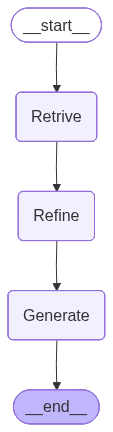

In [68]:
app

In [70]:
res=app.invoke({
    "que":"Explain The bias-variance tradeoff",
    "docs":[],
    "strips":[],
    "kept_strips":[],
    "refined_context":"",
    "answer":""
})



RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '50', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1781049600000'}, 'provider_name': None}}, 'user_id': 'user_3EqtdWc2nqTUmu5jSTbdTvmwh3d'}

In [71]:
print(res["answer"])

NameError: name 'res' is not defined